M.Talha Ramzan
---

2330-0141
---
BS AI
---
lab final AI

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [2]:


df = pd.read_csv("/content/customer_churn_final.csv")

df.head()


,customer_id,churn,age,marital_status,education,salary,account_tenure_months,credit_cards_count,installment_loans_count,ccfp_products_count,...,mobile_banking_usage_pct,avg_current_balance,avg_payment_balance,credit_card_balance_change_3m,credit_card_turnover,payment_turnover,monthly_loan_payment,max_interest_rate,delinquency_percentage,debt_to_loan_ratio
0,146841,0,660,NaN,NaN,NaN,1.593023,0,0,0,...,NaN,156067.339767,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,146842,0,552,NaN,NaN,NaN,1.587647,0,0,0,...,NaN,4278.845817,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,146843,0,420,NaN,NaN,NaN,1.587647,0,0,0,...,0.0,112837.062817,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,146844,0,372,NaN,NaN,NaN,1.583333,0,0,0,...,NaN,42902.902883,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,146845,0,288,NaN,NaN,NaN,1.583333,0,0,0,...,NaN,71906.476533,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [3]:
print("Shape:", df.shape)
print("\nInfo:\n")
df.info()


Shape: (355190, 25)

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355190 entries, 0 to 355189
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    355190 non-null  int64  
 1   churn                          355190 non-null  int64  
 2   age                            355190 non-null  int64  
 3   marital_status                 68234 non-null   object 
 4   education                      68104 non-null   object 
 5   salary                         712 non-null     float64
 6   account_tenure_months          355190 non-null  float64
 7   credit_cards_count             355190 non-null  int64  
 8   installment_loans_count        355190 non-null  int64  
 9   ccfp_products_count            355190 non-null  int64  
 10  package_type                   355190 non-null  object 
 11  atm_trans_count_3m             255595 non-null  float64
 12  at

In [4]:
df['age'] = np.where(
    df['age'] > 150,
    df['age'] / 12,
    df['age']
)

df['age'] = df['age'].astype(int)

df[['age']].describe()


,age
count,355190.000000
mean,38.095673
std,11.369621
min,14.000000
25%,29.000000
50%,36.000000
75%,46.000000
max,94.000000


In [5]:
df['churn'].value_counts(normalize=True) * 100


,proportion
churn,
0,91.856471
1,8.143529


In [6]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100
})

missing_df[missing_df["Missing %"] > 0].sort_values(
    by="Missing %", ascending=False
)


,Missing Count,Missing %
salary,354478,99.799544
debt_to_loan_ratio,353302,99.468454
monthly_loan_payment,353302,99.468454
delinquency_percentage,347189,97.747403
max_interest_rate,347189,97.747403
education,287086,80.826037
marital_status,286956,80.789437
mobile_banking_usage_pct,200027,56.315493
atm_trans_count_3m,99595,28.039922
atm_trans_amount_3m,99595,28.039922


In [7]:
cols_to_drop = missing_df[
    missing_df["Missing %"] > 90
].index.tolist()

print("Dropping columns:", cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)

print("New Shape:", df.shape)


Dropping columns: ['salary', 'monthly_loan_payment', 'max_interest_rate', 'delinquency_percentage', 'debt_to_loan_ratio']
New Shape: (355190, 20)


In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

df[num_cols].isnull().sum()


,0
customer_id,0
churn,0
age,0
account_tenure_months,0
credit_cards_count,0
installment_loans_count,0
ccfp_products_count,0
atm_trans_count_3m,0
atm_trans_amount_3m,0
total_trans_count_3m,0


In [9]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols


Index(['marital_status', 'education', 'package_type'], dtype='object')

In [10]:
for col in cat_cols:
    df[col].fillna("Unknown", inplace=True)


In [11]:
df.columns



Index(['customer_id', 'churn', 'age', 'marital_status', 'education',
       'account_tenure_months', 'credit_cards_count',
       'installment_loans_count', 'ccfp_products_count', 'package_type',
       'atm_trans_count_3m', 'atm_trans_amount_3m', 'total_trans_count_3m',
       'total_trans_amount_3m', 'mobile_banking_usage_pct',
       'avg_current_balance', 'avg_payment_balance',
       'credit_card_balance_change_3m', 'credit_card_turnover',
       'payment_turnover'],
      dtype='object')

In [12]:
df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

df_encoded.head()


,customer_id,churn,age,account_tenure_months,credit_cards_count,installment_loans_count,ccfp_products_count,atm_trans_count_3m,atm_trans_amount_3m,total_trans_count_3m,...,package_type_103,package_type_104,package_type_105,package_type_107,package_type_108,package_type_109,package_type_301,package_type_K01,package_type_M01,package_type_O01
0,146841,0,55,1.593023,0,0,0,0.406780,0.483032,0.406780,...,False,False,False,False,False,False,False,True,False,False
1,146842,0,46,1.587647,0,0,0,0.333333,0.200000,0.545455,...,False,False,False,False,False,False,False,False,False,False
2,146843,0,35,1.587647,0,0,0,0.366667,0.431656,0.297297,...,False,False,False,False,False,False,False,False,False,False
3,146844,0,31,1.583333,0,0,0,0.588235,0.599272,0.558824,...,False,False,False,False,False,False,False,True,False,False
4,146845,0,24,1.583333,0,0,0,0.620690,0.611610,0.620690,...,False,False,False,False,False,False,False,False,False,False


In [13]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
print(scaler.feature_names_in_)


['customer_id' 'age' 'account_tenure_months' 'credit_cards_count'
 'installment_loans_count' 'ccfp_products_count' 'atm_trans_count_3m'
 'atm_trans_amount_3m' 'total_trans_count_3m' 'total_trans_amount_3m'
 'mobile_banking_usage_pct' 'avg_current_balance' 'avg_payment_balance'
 'credit_card_balance_change_3m' 'credit_card_turnover' 'payment_turnover'
 'marital_status_C' 'marital_status_D' 'marital_status_M'
 'marital_status_N' 'marital_status_T' 'marital_status_Unknown'
 'marital_status_V' 'marital_status_W' 'marital_status_d'
 'marital_status_m' 'marital_status_t' 'marital_status_v'
 'marital_status_w' 'education_AC' 'education_AV' 'education_E'
 'education_H' 'education_HH' 'education_HI' 'education_I' 'education_S'
 'education_SS' 'education_UH' 'education_US' 'education_Unknown'
 'education_a' 'education_e' 'education_h' 'education_i' 'education_s'
 'package_type_102' 'package_type_103' 'package_type_104'
 'package_type_105' 'package_type_107' 'package_type_108'
 'package_type_109'

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (284152, 57)
Test shape: (71038, 57)


In [16]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ann_model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = ann_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

y_pred_ann = (ann_model.predict(X_test) > 0.5).astype(int)


print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ann))



Epoch 1/20
888/888 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9018 - loss: 0.3285 - val_accuracy: 0.9204 - val_loss: 0.2643
Epoch 2/20
888/888 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9187 - loss: 0.2761 - val_accuracy: 0.9204 - val_loss: 0.2611
Epoch 3/20
888/888 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9183 - loss: 0.2709 - val_accuracy: 0.9204 - val_loss: 0.2605
Epoch 4/20
888/888 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9184 - loss: 0.2677 - val_accuracy: 0.9204 - val_loss: 0.2587
Epoch 5/20
888/888 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9177 - loss: 0.2662 - val_accuracy: 0.9204 - val_loss: 0.2569
Epoch 6/20
888/888 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9182 - loss: 0.2634 - val_accuracy: 0.9204 - val_loss: 0.2553
Epoch 7/20
888/888 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9174 - loss: 0.2642 - val_accuracy: 0.9204 - val_loss: 0.2540
Epoch 8/20
888/888 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9188 - loss: 0.2605 - val_accuracy: 0.

In [19]:
# Cell: Decision Tree Evaluation Metrics

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Create & Train Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Metrics
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Precision:", precision_score(y_test, y_pred_dt))
print("Decision Tree Recall:", recall_score(y_test, y_pred_dt))
print("Decision Tree F1 Score:", f1_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9171288606098145
Decision Tree Precision: 0.30078125
Decision Tree Recall: 0.01331028522039758
Decision Tree F1 Score: 0.02549246813441483

Classification Report:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     65253
           1       0.30      0.01      0.03      5785

    accuracy                           0.92     71038
   macro avg       0.61      0.51      0.49     71038
weighted avg       0.87      0.92      0.88     71038

Confusion Matrix:
 [[65074   179]
 [ 5708    77]]


Both ANN and Decision Tree give high accuracy because they predict the majority class (0) very well.
ANN fails to detect class 1 at all (recall = 0), while Decision Tree detects a few class 1 cases.
So, Decision Tree performs slightly better than ANN for this problem.

----



**Part C : Ensemble Learning **


----

In [18]:


# Cell: Random Forest Evaluation Metrics

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Create & Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Metrics
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print("Random Forest F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.918564711844365
Random Forest Precision: 0.0
Random Forest Recall: 0.0
Random Forest F1 Score: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     65253
           1       0.00      0.00      0.00      5785

    accuracy                           0.92     71038
   macro avg       0.46      0.50      0.48     71038
weighted avg       0.84      0.92      0.88     71038

Confusion Matrix:
 [[65253     0]
 [ 5785     0]]


 models are overfitting because they predict the majority class (0) very well but fail on minority class (1).
Random Forest will reduce overfitting and improve generalization, detecting more of class 1 correctly.

----
**part D**
---

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

X_unsupervised = df.drop(['churn', 'customer_id'], axis=1)

print(f"Original shape: {df.shape}")
print(f"Unsupervised dataset shape: {X_unsupervised.shape}")
print(f"\nColumns in unsupervised dataset:\n{X_unsupervised.columns.tolist()}")


numerical_cols = X_unsupervised.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_unsupervised.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {categorical_cols}")

num_imputer = SimpleImputer(strategy='median')
X_unsupervised[numerical_cols] = num_imputer.fit_transform(X_unsupervised[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_unsupervised[categorical_cols] = cat_imputer.fit_transform(X_unsupervised[categorical_cols])

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_unsupervised[col] = le.fit_transform(X_unsupervised[col].astype(str))
    label_encoders[col] = le


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)


X_scaled_df = pd.DataFrame(X_scaled, columns=X_unsupervised.columns)

print(f"\nFinal unsupervised dataset shape: {X_scaled_df.shape}")
print(f"Missing values remaining: {X_scaled_df.isnull().sum().sum()}")


X_unsupervised.to_csv('unsupervised_dataset.csv', index=False)
print("\n Unsupervised dataset saved successfully!")

Original shape: (355190, 20)
Unsupervised dataset shape: (355190, 18)

Columns in unsupervised dataset:
['age', 'marital_status', 'education', 'account_tenure_months', 'credit_cards_count', 'installment_loans_count', 'ccfp_products_count', 'package_type', 'atm_trans_count_3m', 'atm_trans_amount_3m', 'total_trans_count_3m', 'total_trans_amount_3m', 'mobile_banking_usage_pct', 'avg_current_balance', 'avg_payment_balance', 'credit_card_balance_change_3m', 'credit_card_turnover', 'payment_turnover']

Numerical columns: 15
Categorical columns: ['marital_status', 'education', 'package_type']

Final unsupervised dataset shape: (355190, 18)
Missing values remaining: 0

 Unsupervised dataset saved successfully!


In [22]:
df = pd.read_csv("/content/unsupervised_dataset.csv")
df.head()

,age,marital_status,education,account_tenure_months,credit_cards_count,installment_loans_count,ccfp_products_count,package_type,atm_trans_count_3m,atm_trans_amount_3m,total_trans_count_3m,total_trans_amount_3m,mobile_banking_usage_pct,avg_current_balance,avg_payment_balance,credit_card_balance_change_3m,credit_card_turnover,payment_turnover
0,55.0,6,12,1.593023,0.0,0.0,0.0,9,0.406780,0.483032,0.406780,0.483032,0.0,156067.339767,0.0,0.0,0.0,0.0
1,46.0,6,12,1.587647,0.0,0.0,0.0,1,0.333333,0.200000,0.545455,0.394340,0.0,4278.845817,0.0,0.0,0.0,0.0
2,35.0,6,12,1.587647,0.0,0.0,0.0,1,0.366667,0.431656,0.297297,0.399342,0.0,112837.062817,0.0,0.0,0.0,0.0
3,31.0,6,12,1.583333,0.0,0.0,0.0,9,0.588235,0.599272,0.558824,0.552169,0.0,42902.902883,0.0,0.0,0.0,0.0
4,24.0,6,12,1.583333,0.0,0.0,0.0,1,0.620690,0.611610,0.620690,0.611610,0.0,71906.476533,0.0,0.0,0.0,0.0


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

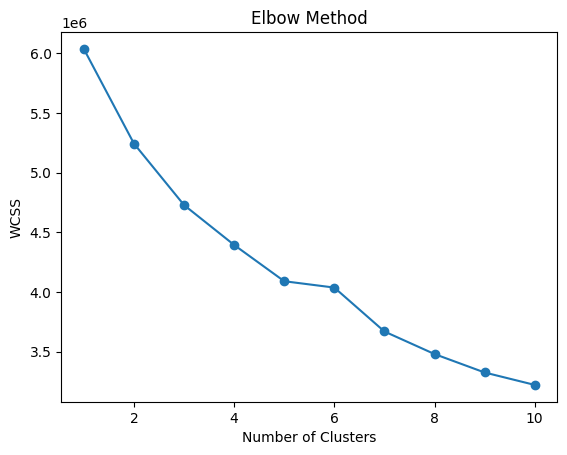

In [25]:
from sklearn.cluster import KMeans

# Scale the 'df' loaded from 'unsupervised_dataset.csv' for clustering
scaler = StandardScaler()
X_unsupervised_scaled = scaler.fit_transform(df)

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to suppress warning
    kmeans.fit(X_unsupervised_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [30]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
silhouette_avg = silhouette_score(X_unsupervised_scaled, y_kmeans)

print(f"Silhouette Score for 5 clusters: {silhouette_avg:.4f}")

KeyboardInterrupt: 

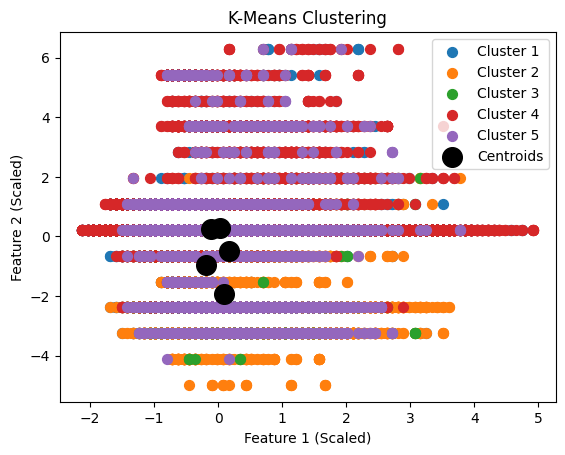

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_unsupervised_scaled)

plt.scatter(X_unsupervised_scaled[y_kmeans==0, 0], X_unsupervised_scaled[y_kmeans==0, 1], s=50, label='Cluster 1')
plt.scatter(X_unsupervised_scaled[y_kmeans==1, 0], X_unsupervised_scaled[y_kmeans==1, 1], s=50, label='Cluster 2')
plt.scatter(X_unsupervised_scaled[y_kmeans==2, 0], X_unsupervised_scaled[y_kmeans==2, 1], s=50, label='Cluster 3')
plt.scatter(X_unsupervised_scaled[y_kmeans==3, 0], X_unsupervised_scaled[y_kmeans==3, 1], s=50, label='Cluster 4')
plt.scatter(X_unsupervised_scaled[y_kmeans==4, 0], X_unsupervised_scaled[y_kmeans==4, 1], s=50, label='Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')

plt.title('K-Means Clustering')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.show()

K-Means clustering does not identify noise points; it assigns every data point to a cluster, so outliers may relay in cluster centroids and reduce model reliability.